# SentinelVision AI
## Notebook 04 — Baseline Anomaly Models

### Objective

Notebook 03 created reusable clip embeddings from real UCF-Crime video clips.

This notebook trains the first anomaly detection models using those embeddings.

We will build:

1. a simple distance-threshold baseline,
2. an Isolation Forest model.

The goal is to establish a clean baseline before moving to deep learning.

The flow is:

`clip embeddings → train on normal training clips → anomaly scores → validation threshold → test evaluation`

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

#### Load embeddings

In [2]:
#embeddings_path = Path("../data/embeddings/clip_embeddings_sample.parquet")
embeddings_path = Path("../data/embeddings/clip_embeddings_videomae_sample.parquet")

embeddings = pd.read_parquet(embeddings_path)

embeddings.shape

(600, 775)

In [3]:
embeddings.head()

,clip_id,video_id,category,binary_label,split,start_seconds,end_seconds,feature_000,feature_001,feature_002,...,feature_758,feature_759,feature_760,feature_761,feature_762,feature_763,feature_764,feature_765,feature_766,feature_767
0,Normal_Videos_365_x264_clip_00003,Normal_Videos_365_x264,Normal,0,test,12.0,16.0,0.178769,3.729066,3.666701,...,2.413040,-1.240642,-1.159237,-1.608377,3.872948,1.565241,0.879731,0.846557,-1.191670,-0.930276
1,Normal_Videos_365_x264_clip_00030,Normal_Videos_365_x264,Normal,0,test,120.0,124.0,0.278189,2.779260,3.542873,...,-0.741295,-1.844295,0.887464,0.550726,3.069808,1.138670,1.094854,0.417987,-1.605511,1.888869
2,Normal_Videos_365_x264_clip_00032,Normal_Videos_365_x264,Normal,0,test,128.0,132.0,0.229807,3.365491,3.970525,...,1.338005,-2.018188,-0.082708,-0.061900,3.764704,1.424313,0.843749,1.016206,-1.329999,1.080641
3,Normal_Videos_641_x264_clip_00015,Normal_Videos_641_x264,Normal,0,test,60.0,64.0,-5.002384,1.898196,0.756616,...,-2.385197,0.084327,4.650817,3.130729,2.914249,-0.534147,2.499364,3.860784,0.763254,-1.158123
4,Normal_Videos_312_x264_clip_00000,Normal_Videos_312_x264,Normal,0,test,0.0,4.0,-4.661326,1.897303,1.866576,...,0.865088,-1.091096,1.328566,4.970067,2.660053,1.487340,2.988191,1.090254,0.692304,0.847159


#### Identify feature columns

In [4]:
feature_columns = [
    column
    for column in embeddings.columns
    if column.startswith("feature_")
]

len(feature_columns), feature_columns[:5]

(768,
 ['feature_000', 'feature_001', 'feature_002', 'feature_003', 'feature_004'])

In [5]:
metadata_columns = [
    column
    for column in embeddings.columns
    if column not in feature_columns
]

metadata_columns

['clip_id',
 'video_id',
 'category',
 'binary_label',
 'split',
 'start_seconds',
 'end_seconds']

#### Split embeddings

In [6]:
train_data = embeddings[
    embeddings["split"] == "train"
].copy()

validation_data = embeddings[
    embeddings["split"] == "validation"
].copy()

test_data = embeddings[
    embeddings["split"] == "test"
].copy()

print("Train:", train_data.shape)
print("Validation:", validation_data.shape)
print("Test:", test_data.shape)

Train: (200, 775)
Validation: (200, 775)
Test: (200, 775)


In [7]:
train_data["binary_label"].value_counts()

binary_label
0    100
1    100
Name: count, dtype: int64

In [8]:
validation_data["binary_label"].value_counts()

binary_label
0    100
1    100
Name: count, dtype: int64

In [9]:
test_data["binary_label"].value_counts()

binary_label
0    100
1    100
Name: count, dtype: int64

#### Train only on normal training clips

In [10]:
normal_train_data = train_data[
    train_data["binary_label"] == 0
].copy()

normal_train_data.shape

(100, 775)

In [11]:
X_train_normal = normal_train_data[feature_columns].values
X_validation = validation_data[feature_columns].values
X_test = test_data[feature_columns].values

y_validation = validation_data["binary_label"].values
y_test = test_data["binary_label"].values

## Part A — Distance Threshold Baseline

#### Scale features

In [12]:
scaler = StandardScaler()

X_train_normal_scaled = scaler.fit_transform(
    X_train_normal
)

X_validation_scaled = scaler.transform(
    X_validation
)

X_test_scaled = scaler.transform(
    X_test
)

#### Compute normal centroid

In [13]:
normal_centroid = X_train_normal_scaled.mean(
    axis=0
)

normal_centroid.shape

(768,)

In [14]:
def centroid_distance_scores(
    X: np.ndarray,
    centroid: np.ndarray,
) -> np.ndarray:
    """
    Compute distance from each sample to the normal centroid.

    Larger distance = more anomalous.
    """
    distances = np.linalg.norm(
        X - centroid,
        axis=1,
    )

    return distances

In [15]:
validation_distance_scores = centroid_distance_scores(
    X_validation_scaled,
    normal_centroid,
)

test_distance_scores = centroid_distance_scores(
    X_test_scaled,
    normal_centroid,
)

#### Pick threshold using validation set

In [16]:
precision, recall, thresholds = precision_recall_curve(
    y_validation,
    validation_distance_scores,
)

f1_scores = []

for threshold in thresholds:
    predictions = (
        validation_distance_scores >= threshold
    ).astype(int)

    score = f1_score(
        y_validation,
        predictions,
        zero_division=0,
    )

    f1_scores.append(score)

best_index = int(np.argmax(f1_scores))
best_distance_threshold = thresholds[best_index]
best_validation_f1 = f1_scores[best_index]

best_distance_threshold, best_validation_f1

(np.float64(28.928040959706077), 0.758893280632411)

#### Evaluate distance baseline on test set

In [17]:
test_distance_predictions = (
    test_distance_scores >= best_distance_threshold
).astype(int)

In [18]:
distance_results = {
    "model": "Distance Threshold Baseline",
    "roc_auc": roc_auc_score(
        y_test,
        test_distance_scores,
    ),
    "pr_auc": average_precision_score(
        y_test,
        test_distance_scores,
    ),
    "f1": f1_score(
        y_test,
        test_distance_predictions,
        zero_division=0,
    ),
}

distance_results

{'model': 'Distance Threshold Baseline',
 'roc_auc': 0.6950000000000001,
 'pr_auc': 0.7743263493141134,
 'f1': 0.6289752650176679}

In [19]:
print(
    classification_report(
        y_test,
        test_distance_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           0       0.35      0.06      0.10       100
           1       0.49      0.89      0.63       100

    accuracy                           0.47       200
   macro avg       0.42      0.47      0.37       200
weighted avg       0.42      0.47      0.37       200



## Part B — Isolation Forest

#### Train Isolation Forest

In [20]:
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)

isolation_forest.fit(
    X_train_normal_scaled
)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


#### Score validation and test data

In [21]:
# sklearn returns higher decision_function values for more normal samples.
# We multiply by -1 so higher score means more anomalous.
validation_iforest_scores = -isolation_forest.decision_function(
    X_validation_scaled
)

test_iforest_scores = -isolation_forest.decision_function(
    X_test_scaled
)

#### Pick Isolation Forest threshold using validation set

In [22]:
precision, recall, thresholds = precision_recall_curve(
    y_validation,
    validation_iforest_scores,
)

f1_scores = []

for threshold in thresholds:
    predictions = (
        validation_iforest_scores >= threshold
    ).astype(int)

    score = f1_score(
        y_validation,
        predictions,
        zero_division=0,
    )

    f1_scores.append(score)

best_index = int(np.argmax(f1_scores))
best_iforest_threshold = thresholds[best_index]
best_iforest_validation_f1 = f1_scores[best_index]

best_iforest_threshold, best_iforest_validation_f1

(np.float64(-0.011903363768938968), 0.7424242424242424)

#### Evaluate Isolation Forest on test set

In [23]:
test_iforest_predictions = (
    test_iforest_scores >= best_iforest_threshold
).astype(int)

In [24]:
iforest_results = {
    "model": "Isolation Forest",
    "roc_auc": roc_auc_score(
        y_test,
        test_iforest_scores,
    ),
    "pr_auc": average_precision_score(
        y_test,
        test_iforest_scores,
    ),
    "f1": f1_score(
        y_test,
        test_iforest_predictions,
        zero_division=0,
    ),
}

iforest_results

{'model': 'Isolation Forest',
 'roc_auc': 0.6658999999999999,
 'pr_auc': 0.7327475557188275,
 'f1': 0.6363636363636364}

In [25]:
print(
    classification_report(
        y_test,
        test_iforest_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           0       0.36      0.05      0.09       100
           1       0.49      0.91      0.64       100

    accuracy                           0.48       200
   macro avg       0.42      0.48      0.36       200
weighted avg       0.42      0.48      0.36       200



## Part C — Compare Baselines

#### Results table

In [26]:
results = pd.DataFrame(
    [
        distance_results,
        iforest_results,
    ]
)

results

,model,roc_auc,pr_auc,f1
0,Distance Threshold Baseline,0.6950,0.774326,0.628975
1,Isolation Forest,0.6659,0.732748,0.636364


In [27]:
results.sort_values(
    by="pr_auc",
    ascending=False,
)

,model,roc_auc,pr_auc,f1
0,Distance Threshold Baseline,0.6950,0.774326,0.628975
1,Isolation Forest,0.6659,0.732748,0.636364


#### Plot score distributions

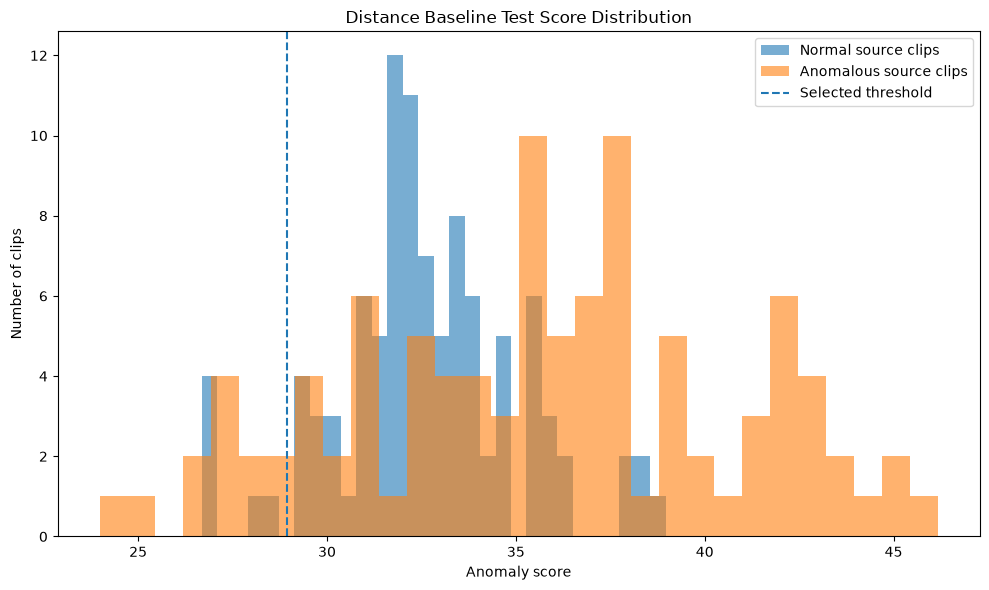

In [28]:
plt.figure(figsize=(10, 6))

plt.hist(
    test_distance_scores[y_test == 0],
    bins=30,
    alpha=0.6,
    label="Normal source clips",
)

plt.hist(
    test_distance_scores[y_test == 1],
    bins=30,
    alpha=0.6,
    label="Anomalous source clips",
)

plt.axvline(
    best_distance_threshold,
    linestyle="--",
    label="Selected threshold",
)

plt.title("Distance Baseline Test Score Distribution")
plt.xlabel("Anomaly score")
plt.ylabel("Number of clips")
plt.legend()
plt.tight_layout()
plt.show()

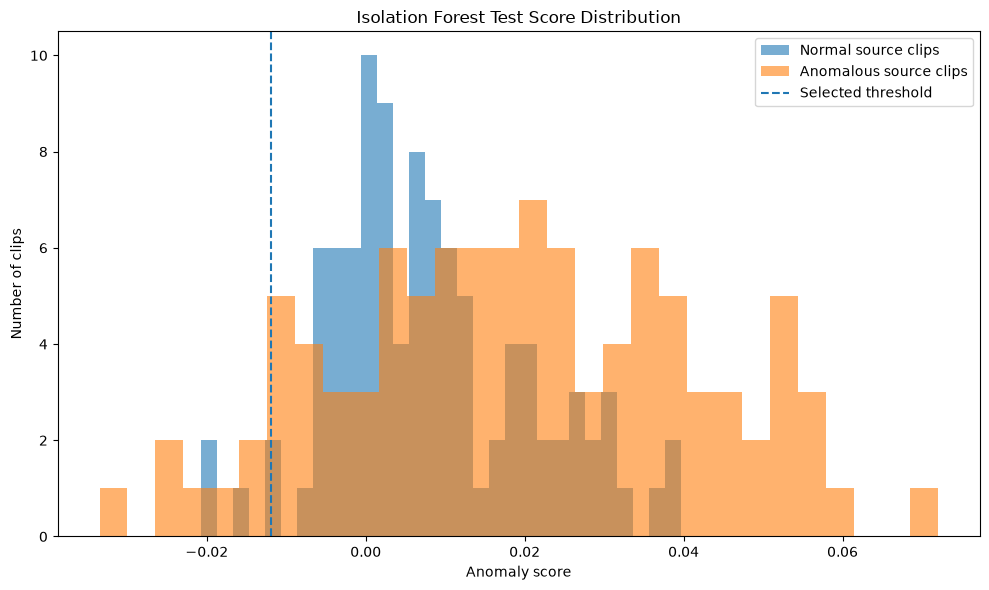

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(
    test_iforest_scores[y_test == 0],
    bins=30,
    alpha=0.6,
    label="Normal source clips",
)

plt.hist(
    test_iforest_scores[y_test == 1],
    bins=30,
    alpha=0.6,
    label="Anomalous source clips",
)

plt.axvline(
    best_iforest_threshold,
    linestyle="--",
    label="Selected threshold",
)

plt.title("Isolation Forest Test Score Distribution")
plt.xlabel("Anomaly score")
plt.ylabel("Number of clips")
plt.legend()
plt.tight_layout()
plt.show()

#### Save models and results

In [30]:
models_dir = Path("../models/production")
metrics_dir = Path("../artifacts/metrics")

models_dir.mkdir(
    parents=True,
    exist_ok=True,
)

metrics_dir.mkdir(
    parents=True,
    exist_ok=True,
)

In [31]:
joblib.dump(
    scaler,
    models_dir / "baseline_scaler.joblib",
)

joblib.dump(
    {
        "normal_centroid": normal_centroid,
        "threshold": best_distance_threshold,
    },
    models_dir / "distance_baseline.joblib",
)

joblib.dump(
    {
        "model": isolation_forest,
        "threshold": best_iforest_threshold,
    },
    models_dir / "isolation_forest.joblib",
)

['..\\models\\production\\isolation_forest.joblib']

In [32]:
results.to_csv(
    metrics_dir / "baseline_model_results.csv",
    index=False,
)

results

,model,roc_auc,pr_auc,f1
0,Distance Threshold Baseline,0.6950,0.774326,0.628975
1,Isolation Forest,0.6659,0.732748,0.636364


# Conclusion

Notebook 04 trained the first anomaly detection models for SentinelVision AI.

## What was built

Two baseline models were trained:

1. Distance Threshold Baseline
2. Isolation Forest

Both models used the clip embeddings created in Notebook 03.

## Modeling flow

The modeling flow was:

`normal training clips → anomaly scoring → validation threshold → test evaluation`

## Why this matters

These baselines establish a performance floor.

Any deeper model must justify its extra complexity by improving on these results.

## Important limitation

The labels are inherited from source videos.

A clip from an anomalous video may not contain the actual anomalous event.

Therefore, these metrics should be interpreted as weak-label evaluation, not perfect frame-level anomaly localization.

## Output created

- `models/production/baseline_scaler.joblib`
- `models/production/distance_baseline.joblib`
- `models/production/isolation_forest.joblib`
- `artifacts/metrics/baseline_model_results.csv`

## Next notebook

Notebook 05 will train a deep reconstruction model:

`clip embeddings → autoencoder → reconstruction error → anomaly threshold → evaluation`